Source data: https://open.toronto.ca/dataset/bicycle-thefts/, used version from April 23, 2026. Contains information on bicycle thefts in Toronto, including location, date, and type of theft.


In [1]:
#Loading packages
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

#Loading the data
df = pd.read_csv("/Users/darahvlaminck/Desktop/bicycle-thefts - 4326.csv")
df.head()

,_id,EVENT_UNIQUE_ID,PRIMARY_OFFENCE,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DOW,OCC_DAY,OCC_DOY,OCC_HOUR,...,BIKE_MAKE,BIKE_MODEL,BIKE_TYPE,BIKE_SPEED,BIKE_COLOUR,BIKE_COST,STATUS,LONG_WGS84,LAT_WGS84,geometry
0,1,GO-20141261431,THEFT UNDER,2014-01-01,2014,January,Wednesday,1,1,7,...,SUPERCYCLE,NaN,MT,10.0,NaN,NaN,STOLEN,-79.443645,43.637657,"{""coordinates"": [[-79.4436451189999, 43.637657..."
1,2,GO-20141263784,PROPERTY - FOUND,2014-01-01,2014,January,Wednesday,1,1,18,...,TREK,SOHO S,RG,1.0,BLK,NaN,RECOVERED,-79.414654,43.660525,"{""coordinates"": [[-79.41465353, 43.66052480500..."
2,3,GO-20141263544,B&E,2013-12-26,2013,December,Thursday,26,360,19,...,FELT,F59,RC,21.0,SILRED,1300.0,STOLEN,-79.395643,43.640021,"{""coordinates"": [[-79.395642735, 43.640020679]..."
3,4,GO-20141266048,THEFT UNDER,2013-12-30,2013,December,Monday,30,364,17,...,KHS,VITAMIN A,OT,24.0,WHI,500.0,STOLEN,-79.429566,43.718425,"{""coordinates"": [[-79.429565692, 43.718424763]..."
4,5,GO-20149000071,THEFT UNDER,2013-12-25,2013,December,Wednesday,25,359,10,...,BI,NaN,TO,25.0,RED,400.0,STOLEN,-79.373767,43.667288,"{""coordinates"": [[-79.3737671549999, 43.667288..."


In [2]:
## Bicycle thefts over time
#Thefts by month by year
# Group the data by year and month, and count the number of thefts in each group


#Only want the  last 7 years of data so the graph is not too cluttered. We will filter the data to only include the years 2018-2025.
YEAR_START, YEAR_END = 2018, 2025
df = df[(df['OCC_YEAR'] >= YEAR_START) & (df['OCC_YEAR'] <= YEAR_END)]

#Need to make sure the month is in numeric format for plotting, so we will map the month names to numbers using a dictionary.
MONTH_NAME_TO_NUM = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['month'] = df['OCC_MONTH'].map(MONTH_NAME_TO_NUM)
 
 
#Group by month, year
monthly_counts = (
    df.groupby(['OCC_YEAR', 'month'])
    .size()
    .reset_index(name='theft_count')
)
 
#Pivot table to make it easier to plot
pivot = monthly_counts.pivot(index='month', columns='OCC_YEAR', values='theft_count')
pivot = pivot.reindex(range(1, 13))  # ensure all 12 months present, in order, even if a month had 0 thefts in some year
pivot = pivot.fillna(0)
 
#Data we need for plotting
years = pivot.columns.tolist()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


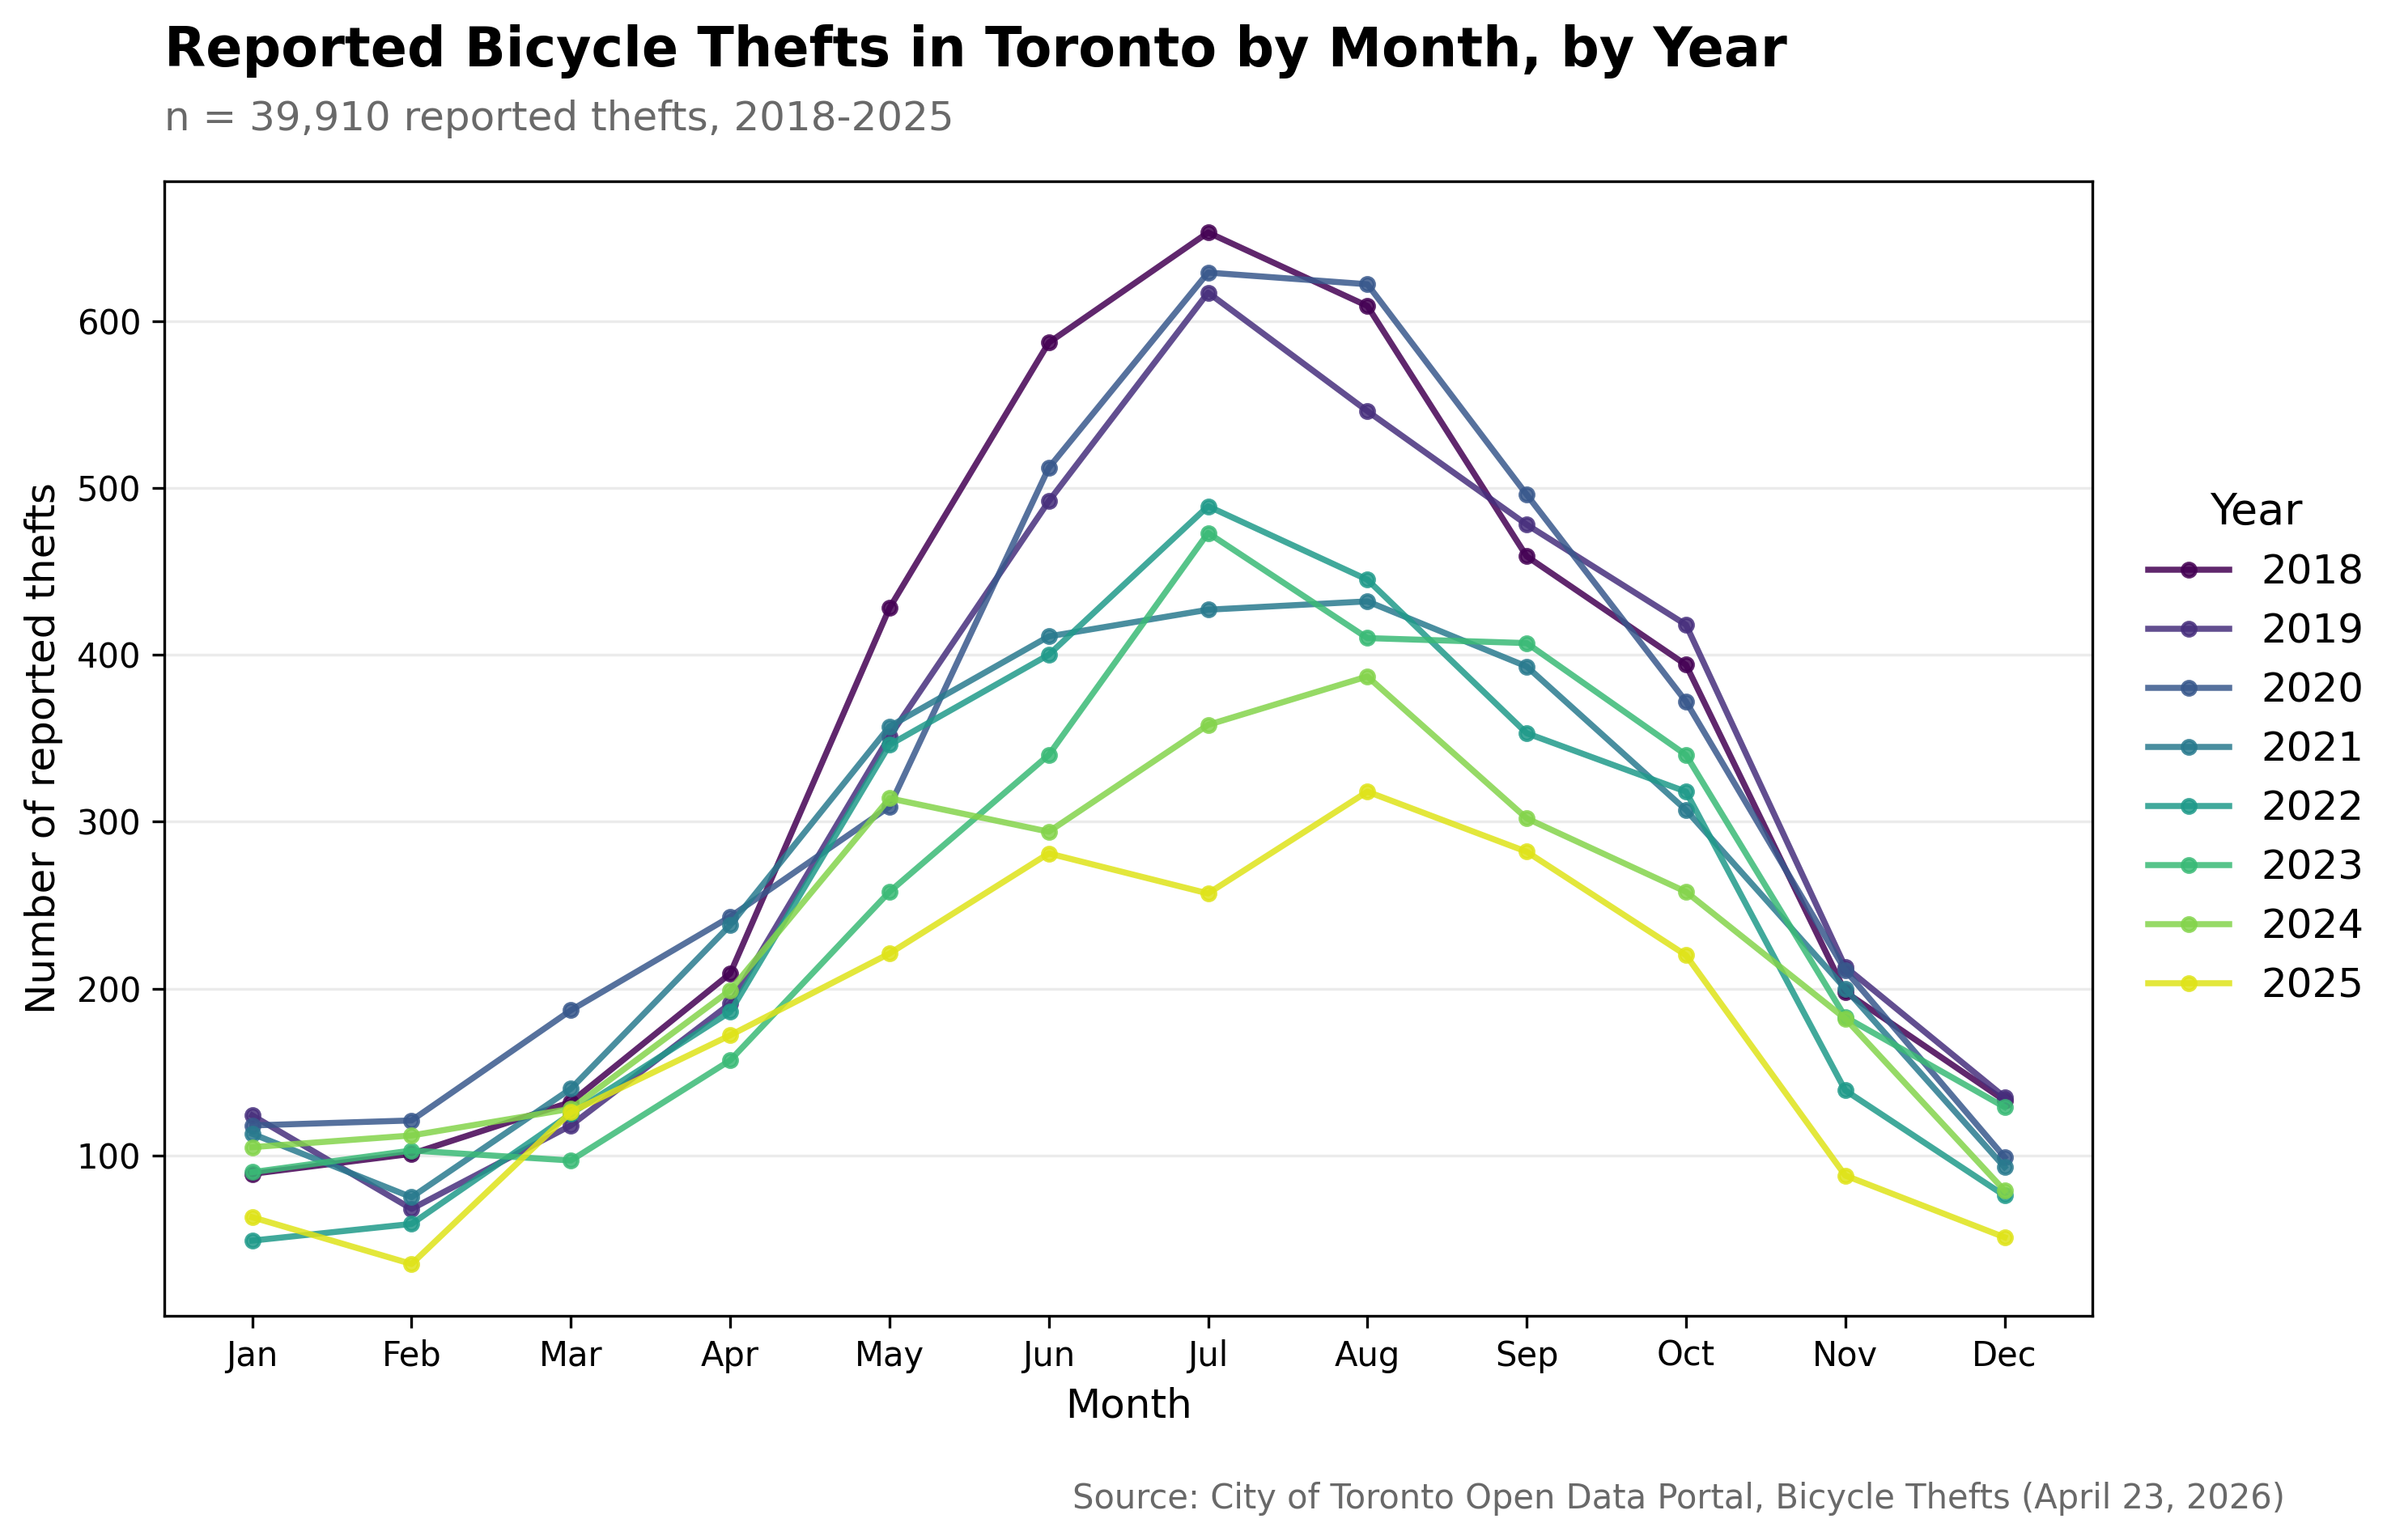

In [19]:
n_years = len(years)
colors = cm.viridis(np.linspace(0, 0.95, n_years)) #Viridis to be colourblind friendly


fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300) #Create a figure and axis object for the plot, dpi is set to 300 for high resolution

#Loop through each year and plot the data for that year
for i, year in enumerate(years):
    ax.plot(
        month_labels,
        pivot[year].values, #Get the values for the year
        color=colors[i],
        linewidth=1.8,
        alpha=0.85,
        marker='o',
        markersize=4,
        label=str(year)
    )

#Add labels and gridlines to the plot
ax.set_ylabel('Number of reported thefts', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.grid(axis='y', linestyle='-', alpha=0.25, zorder=0) #Only show grid lines for the y-axis, with a light alpha so they don't overpower the data

#Set the title and subtitle for the plot
ax.set_title(
    'Reported Bicycle Thefts in Toronto by Month, by Year',
    fontsize=16,
    fontweight='bold',
    pad=34,
    loc='left'
)
ax.text(
    0.0, 1.045, f'n = {len(df):,} reported thefts, {years[0]}-{years[-1]}',
    transform=ax.transAxes,
    ha='left', fontsize=12, color='dimgray'
)
#Add a source note to the bottom of the plot
ax.text(
    1.1, -0.17, 'Source: City of Toronto Open Data Portal, Bicycle Thefts (April 23, 2026)',
    transform=ax.transAxes,
    ha='right', fontsize=10, color='dimgray'
)

#Legend settings
ax.legend(
    title='Year',
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    fontsize=12,
    title_fontsize=13,
    frameon=False
)

#Export the figure
plt.tight_layout()
plt.savefig('/Users/darahvlaminck//Desktop/UofT Miscellaneous/DSI Certificate/visualization/02_activities/assignments/assignment 3/Bike_Theft_Counts_Toronto_Vis1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

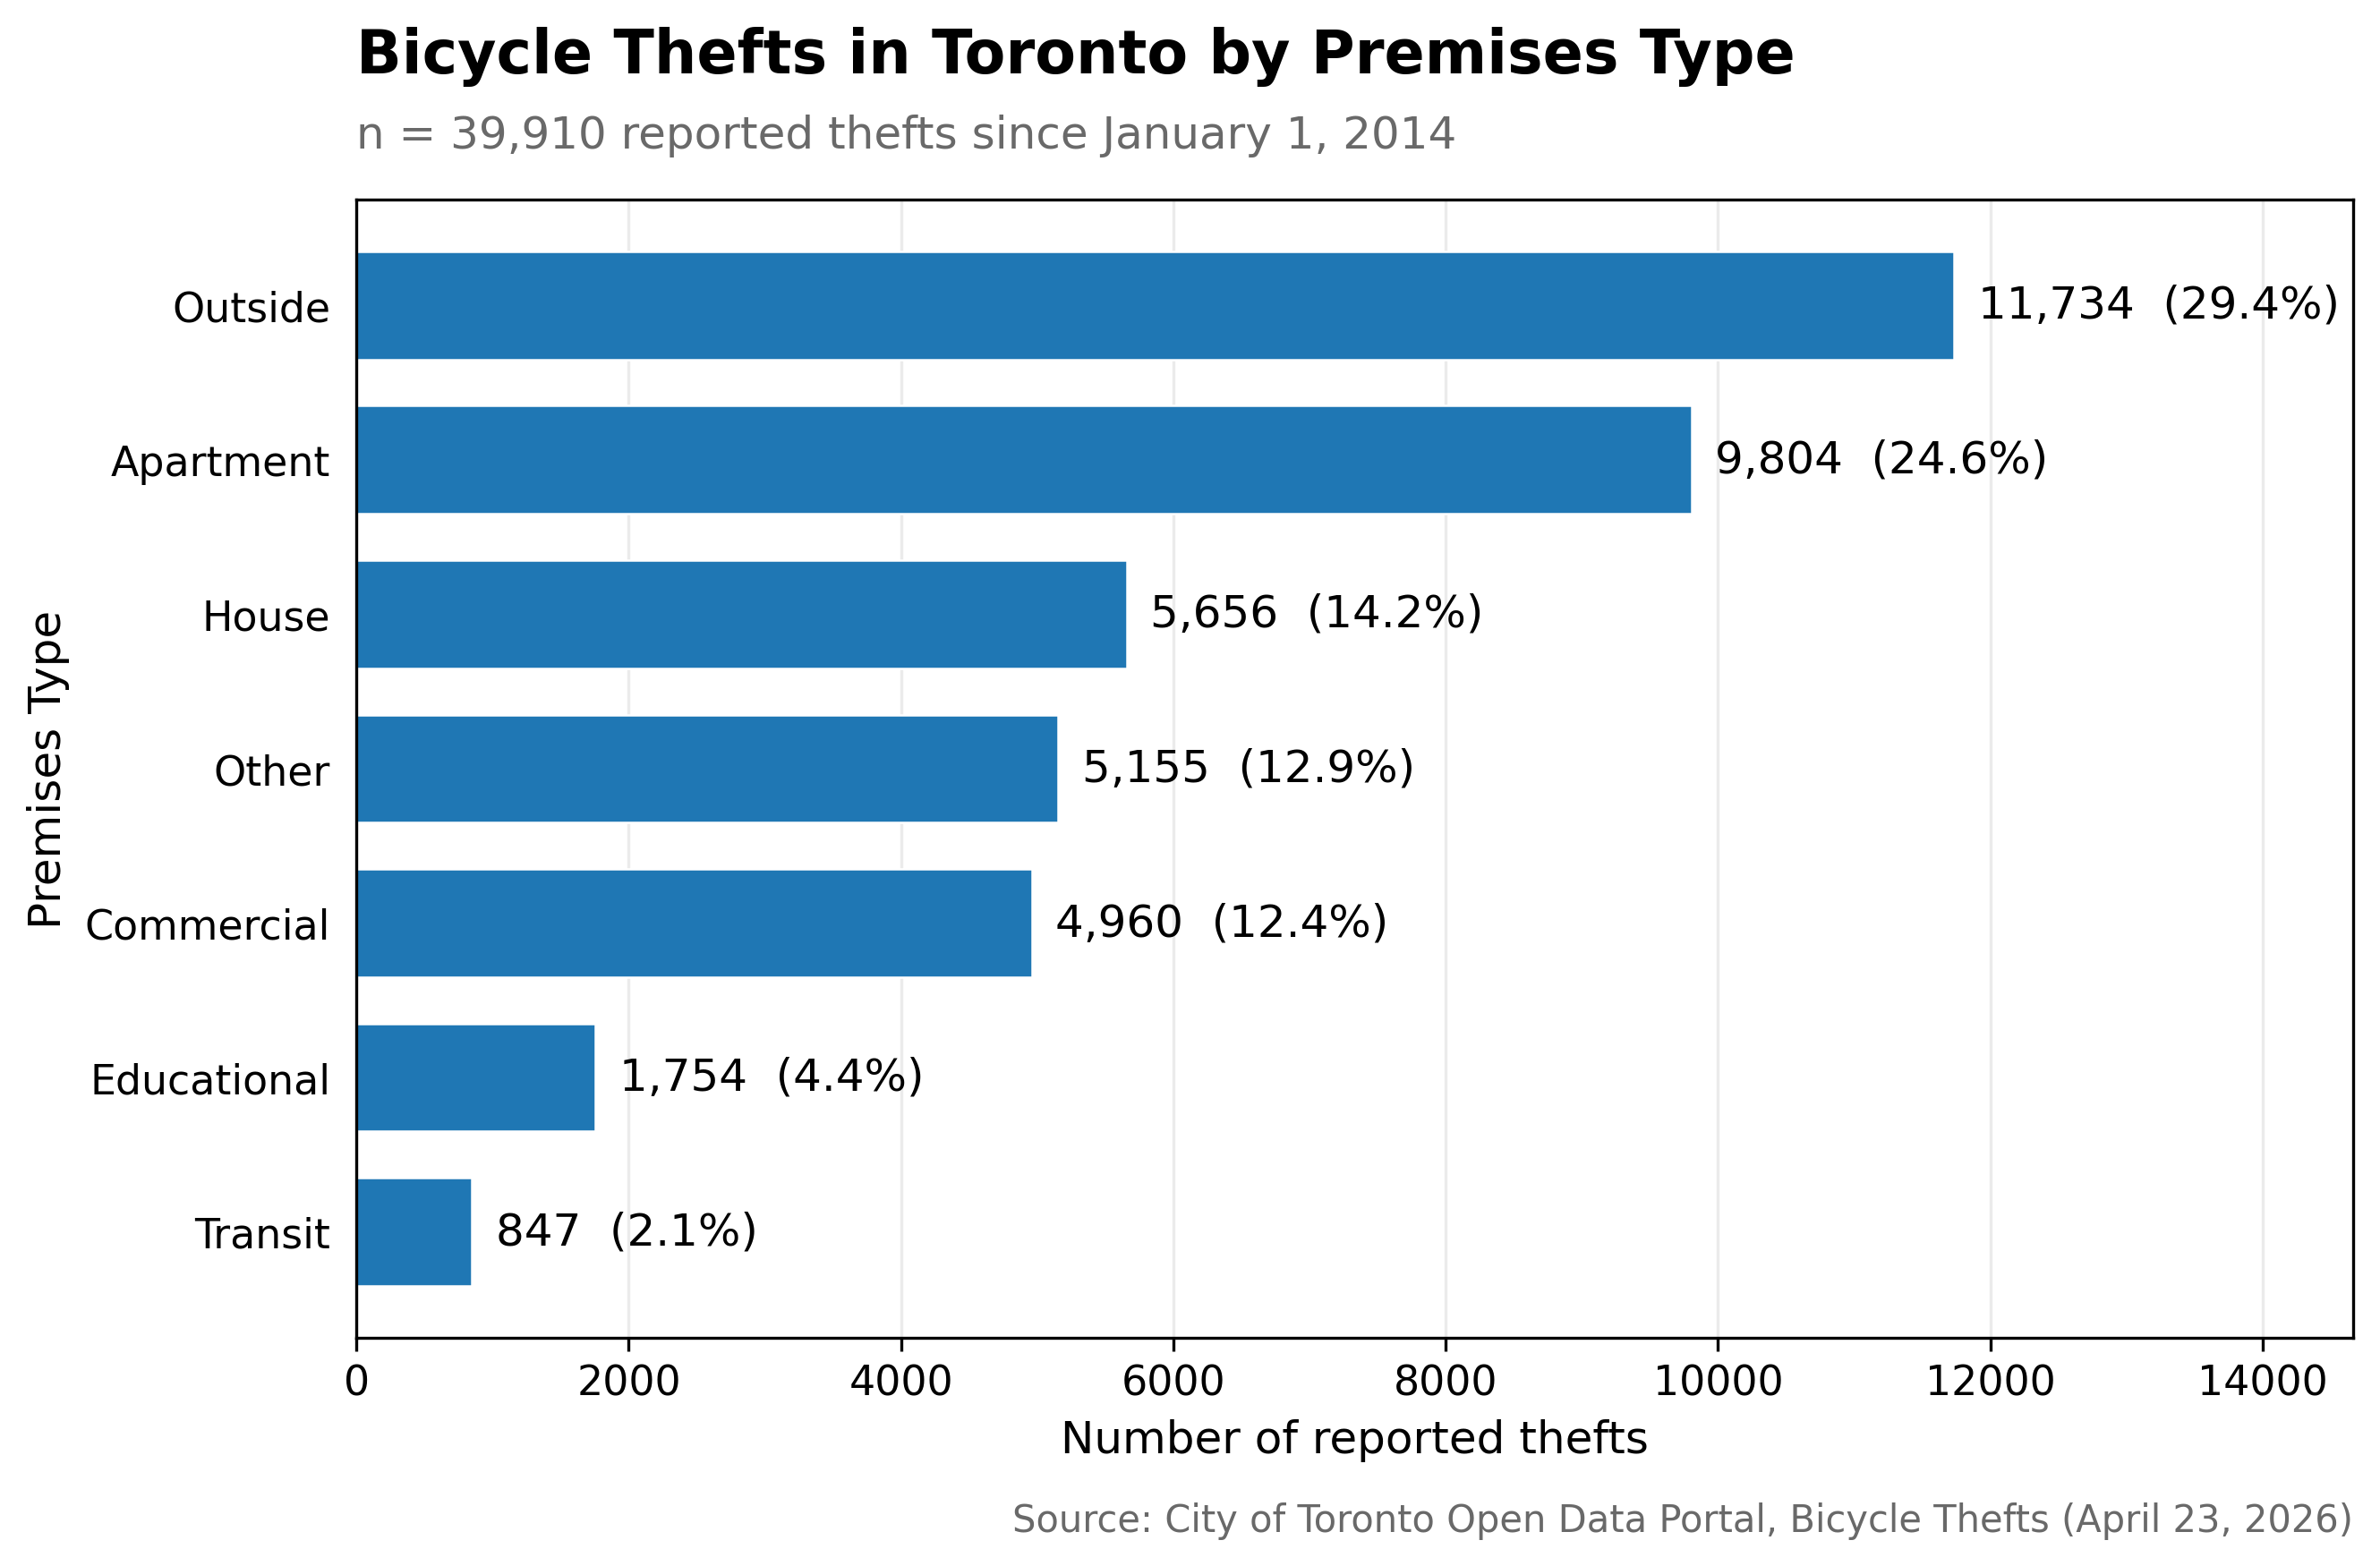

In [21]:
#Location of Bike Thefts in Toronto
#Reread in dataframe since other plot was filtered
df = pd.read_csv("/Users/darahvlaminck/Desktop/bicycle-thefts - 4326.csv")

#Only keeping events 2014 and after. The data states it is only complete from 2014 onwards, so we will filter the data to only include the years 2014-2026. (Some occurances are before 2014 but they didn't report them until 2014 or later)
YEAR_START  = 2014
df = df[df['OCC_YEAR'] >= YEAR_START]

#Get the premises type for each theft, and count the number of thefts for each premises type
premises_counts = df['PREMISES_TYPE'].value_counts().sort_values(ascending=True)
total = len(df)

#Set style for the plot
bar_color = '#1f77b4'  #A shade of blue

fig, ax = plt.subplots(figsize=(9, 6), dpi=300) #Create a figure and axis object for the plot, dpi is set to 300 for high resolution

#Create a horizontal bar chart for the premises type counts
bars = ax.barh(
    premises_counts.index,
    premises_counts.values,
    color=bar_color, #Make the bars colour chose above
    edgecolor='white',
    linewidth=0.6,
    height=0.7
)

#Create a percentage label for each bar for easier readibility
max_val = premises_counts.max()
for bar, value in zip(bars, premises_counts.values):
    pct = value / total
    ax.text(
        bar.get_width() + max_val * 0.015, #Add a small offset to the right of the bar for the label
        bar.get_y() + bar.get_height() / 2, #Center the label vertically on the bar
        f'{value:,}  ({pct:.1%})', #Format the label to show the count and percentage
        va='center', ha='left', fontsize=12
    )

#Add labels and gridlines to the plot
ax.set_ylabel('Premises Type', fontsize=12)
ax.set_xlabel('Number of reported thefts', fontsize=12)
ax.set_xlim(0, max_val * 1.25) #Need this otherwise the labels will be cut off on the right side of the plot
ax.grid(axis='x', linestyle='-', alpha=0.25, zorder=0) #Only show grid lines for the x-axis, with a light alpha so they don't overpower the data
ax.set_axisbelow(True) #So the grid lines are below the bars
ax.tick_params(left=False, labelsize=11) #Remove left ticks for aesthetic purposes

#Set the title and subtitle for the plot
ax.set_title(
    'Bicycle Thefts in Toronto by Premises Type',
    fontsize=16, fontweight='bold', loc='left', pad=34
)
ax.text(
    0.0, 1.045, f'n = {total:,} reported thefts since January 1, {YEAR_START}',
    transform=ax.transAxes, ha='left', fontsize=12, color='dimgray'
)
#Add a source note to the bottom of the plot
ax.text(
    1.0, -0.17, 'Source: City of Toronto Open Data Portal, Bicycle Thefts (April 23, 2026)',
    transform=ax.transAxes,
    ha='right', fontsize=10, color='dimgray'
)

#Export the figure
plt.tight_layout()
plt.savefig('/Users/darahvlaminck//Desktop/UofT Miscellaneous/DSI Certificate/visualization/02_activities/assignments/assignment 3/Bike_Theft_Premises_Vis2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()